Linear Mixed Model Analysis

In [1]:
### Set Paths for Statistical Analysis
visgam_dir  <- dirname(getwd())
results_dir <- file.path(visgam_dir, "Results", "SNR_Controls", "Revision_IN")
print(x = paste0("Results directory: ", results_dir))


[1] "Results directory: e:/ongoing/Visgam/Results/SNR_Controls/Revision_IN"


In [2]:
### ----- Path to dataset ----- ###
dataset     <- file.path(results_dir, "results_alpha", "alpha_peaks 10_20.csv")
f_band      <- "Alpha" # Alpha

### Load Packages 
library(tidyr)
library(dplyr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [3]:
##### Long Format CSV
### ----- Read Dataset 
df      <- read.csv(dataset)

### ----- Transform to Long Format
df_long <- df %>%
  pivot_longer(
    cols = c(pf_opm, pf_eeg, pp_opm, pp_eeg),
    names_to = c("Measure", "Modality"),
    names_pattern = "^([^_]+)_([^_]+)(?:_.+)?$",
    values_to = "Value"
  ) %>%
  mutate(
    Measure  = dplyr::recode(Measure, "pf"=paste0("Peak_Freq_", f_band), "pp"=paste0("Peak_Power_", f_band)),
    Modality = dplyr::recode(Modality, "opm"="OPM", "eeg"="EEG"),
    SZ_EEG_INFO = factor(SZ_EEG_INFO, levels=c(0,1), labels=c("Control","Patient"))
  ) %>%
  filter(SZ_EEG_INFO == "Control")
  
df_model <- df_long %>%
  filter(Measure == paste0("Peak_Power_", f_band)) %>%
  mutate(Modality = factor(Modality))

In [4]:
### Load Packages for Statistical Analysis
library(lme4)
library(MuMIn)
library(lmerTest)
library(car)
library(performance)
#https://stat.ethz.ch/~meier/teaching/anova/random-and-mixed-effects-models.html#mixed-effects-models
library(effectsize)
library(emmeans)

Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack



Attaching package: 'lmerTest'


The following object is masked from 'package:lme4':

    lmer


The following object is masked from 'package:stats':

    step


Loading required package: carData


Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode


Warning message:
"package 'performance' was built under R version 4.5.2"
Warning message:
"package 'effectsize' was built under R version 4.5.2"
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [5]:
### Define model formula
ModelAnalysis <- lmer(
  Value ~ Modality + CommonTrials + (1 | DatasetID),
  data = df_model
)
### Print Summary
ampsum    <- summary(ModelAnalysis)
model_amp <- as.data.frame(round(ampsum$coefficients, 3))
ampsum

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Value ~ Modality + CommonTrials + (1 | DatasetID)
   Data: df_model

REML criterion at convergence: 214.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.57781 -0.50333 -0.00589  0.33132  2.06724 

Random effects:
 Groups    Name        Variance Std.Dev.
 DatasetID (Intercept) 2.840    1.685   
 Residual              1.587    1.260   
Number of obs: 52, groups:  DatasetID, 26

Fixed effects:
             Estimate Std. Error       df t value Pr(>|t|)   
(Intercept)   8.69518    3.36192 24.12995   2.586  0.01616 * 
ModalityOPM  -1.27152    0.34938 25.00000  -3.639  0.00124 **
CommonTrials -0.01651    0.01843 24.00000  -0.896  0.37929   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr) MdlOPM
ModalityOPM -0.052       
CommonTrils -0.992  0.000


	Shapiro-Wilk normality test

data:  resid(ModelAnalysis)
W = 0.9767, p-value = 0.3966


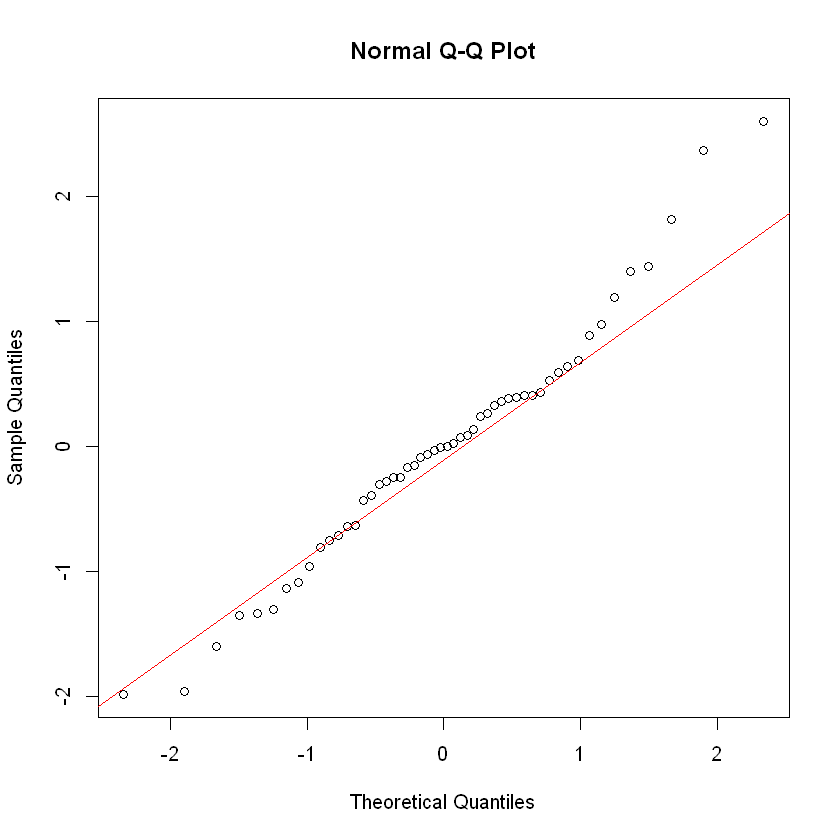

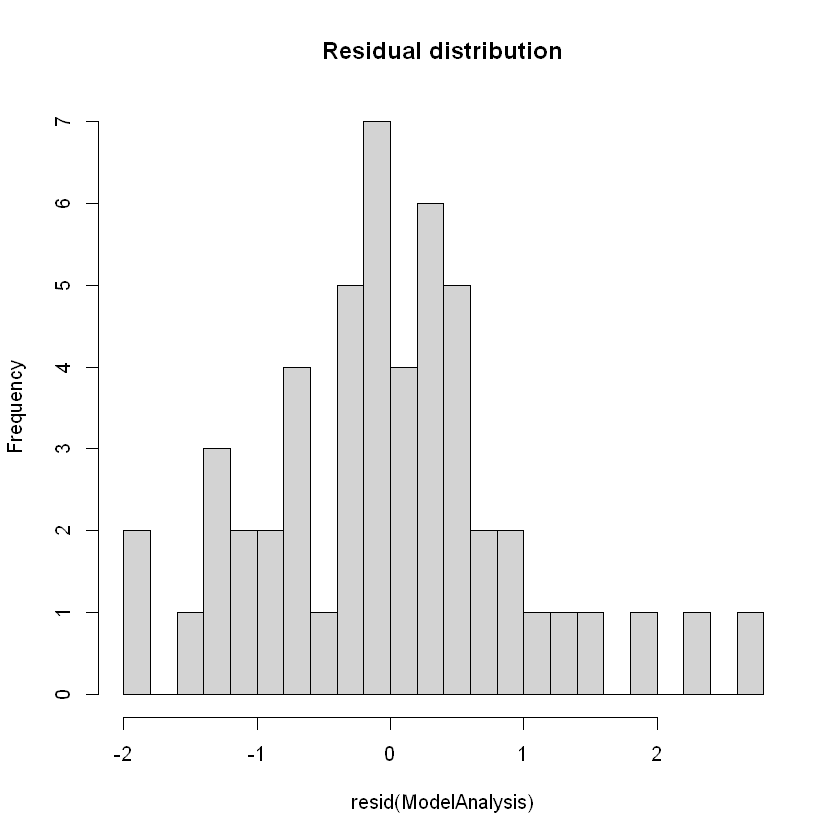

In [6]:
### Shapiro-Wilk test
shapiro.test(resid(ModelAnalysis))

### QQ plot
qqnorm(resid(ModelAnalysis)); qqline(resid(ModelAnalysis), col = "red")

### Histogram
hist(resid(ModelAnalysis), breaks = 30, main = "Residual distribution")

In [7]:
### Print Analysis of Fixed Effects
print("Fixed effects analysis")
aovamp <- anova(ModelAnalysis, type="II", test="F")
print(aovamp)
eff   <- eta_squared(aovamp, alternative="two.sided")
round(eff$Eta2_partial, 3)
round(eff$CI_low, 3)
round(eff$CI_high, 3)

aovamp <- round(as.data.frame(aovamp), 3)
aovamp

[1] "Fixed effects analysis"
Type II Analysis of Variance Table with Satterthwaite's method
              Sum Sq Mean Sq NumDF DenDF F value   Pr(>F)   
Modality     21.0179 21.0179     1    25 13.2452 0.001243 **
CommonTrials  1.2732  1.2732     1    24  0.8023 0.379294   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


[1] 0.346 0.032

[1] 0.074 0.000

[1] 0.575 0.254

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Modality,21.018,21.018,1,25,13.245,0.001
CommonTrials,1.273,1.273,1,24,0.802,0.379


In [8]:
### Print Effect Size
df_wide <- df_model |>
  select(DatasetID, Modality, Value) |>
  pivot_wider(names_from = Modality, values_from = Value)

### Caculate Cohen's d and Hedges' g
D   <- df_wide$OPM - df_wide$EEG
dz  <- mean(D) / sd(D)
n   <- length(D)
g_z <- dz * (1 - 3/(4*n - 9))
print("Hedges' g")
round(g_z, 3)
print("Cohen's d")
round(dz, 3)

### Calculate Probability of OPM Superiority
n_total         <- nrow(df_wide)
n_opm_better    <- sum(df_wide$OPM > df_wide$EEG)
cles            <- (n_opm_better / n_total) * 100

print("Probability of OPM superiority")
round(cles, 1)

n_opm_better

[1] "Hedges' g"


[1] -0.691

[1] "Cohen's d"


[1] -0.714

[1] "Probability of OPM superiority"


[1] 23.1

[1] 6